In [2]:
import pandas as pd
import numpy as np

In [13]:
df=pd.read_csv("/home/philipp/Downloads/LiDAR_Data_ANH_2013-2014.csv")

In [16]:
df.head()

,DataTimeStamp,ExtTemp,Pressure,RelHumidity,ScanAngle,DirectionOffSet,1_WindSpeed,1_WindSpeedDispersion,1_WindSpeedMin,1_WindSpeedMax,...,12_WindSpeedMin,12_WindSpeedMax,12_WindDirection,12_Z-wind,12_Z-windDispersion,12_CNR,12_CNRmin,12_DoppSpectBroad,12_DataAvailability,12_Altitude
DataTimeStamp,,,,,,,,,,,,,,,,,,,,,
2013-01-01 00:00:00,2013-01-01 00:00:00.000,NaN,NaN,NaN,28,-20.7,17.06,0.35,NaN,18.05,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-01-01 00:10:00,2013-01-01 00:10:00.000,NaN,NaN,NaN,28,-20.7,17.06,0.36,NaN,18.25,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-01-01 00:20:00,2013-01-01 00:20:00.000,NaN,NaN,NaN,28,-20.7,16.78,0.40,NaN,18.37,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-01-01 00:30:00,2013-01-01 00:30:00.000,NaN,NaN,NaN,28,-20.7,16.63,0.36,NaN,17.55,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-01-01 00:40:00,2013-01-01 00:40:00.000,NaN,NaN,NaN,28,-20.7,16.51,0.34,NaN,17.53,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [100]:
df["2_WindSpeed"].resample("h").mean()

DataTimeStamp
2013-01-01 00:00:00    17.175000
2013-01-01 01:00:00    14.558333
2013-01-01 02:00:00    11.493333
2013-01-01 03:00:00    10.711667
2013-01-01 04:00:00     9.636667
                         ...    
2014-12-30 20:00:00     9.985000
2014-12-30 21:00:00     9.943333
2014-12-30 22:00:00     8.753333
2014-12-30 23:00:00     8.268333
2014-12-31 00:00:00     8.510000
Freq: H, Name: 2_WindSpeed, Length: 17497, dtype: float64

In [101]:
df["2_WindSpeed"]

DataTimeStamp
2013-01-01 00:00:00    17.53
2013-01-01 00:10:00    17.56
2013-01-01 00:20:00    17.51
2013-01-01 00:30:00    17.32
2013-01-01 00:40:00    16.86
                       ...  
2014-12-30 23:20:00     9.03
2014-12-30 23:30:00     8.09
2014-12-30 23:40:00     8.15
2014-12-30 23:50:00     8.19
2014-12-31 00:00:00     8.51
Name: 2_WindSpeed, Length: 104584, dtype: float64

In [15]:
df.index=pd.to_datetime(df["DataTimeStamp"])

In [19]:
df["2_WindSpeed"].describe()

count    104191.000000
mean          9.014595
std           4.277750
min           0.200000
25%           5.720000
50%           8.720000
75%          12.020000
max          34.530000
Name: 2_WindSpeed, dtype: float64

In [92]:
data=[]
for period in np.arange(1,7):
    df[f"difference_{period}"]=df["2_WindSpeed"].diff(periods=period)
    data.append(np.abs(df[f"difference_{period}"].iloc[period:]).dropna().sort_values())

In [72]:
np.arange(1,7)

array([1, 2, 3, 4, 5, 6])

In [75]:
data[0].describe()

count    52212.000000
mean         0.380419
std          0.378820
min          0.000000
25%          0.130000
50%          0.280000
75%          0.510000
max         11.290000
Name: difference_1, dtype: float64

In [76]:
data[5].describe()

count    52147.000000
mean         0.950759
std          0.918156
min          0.000000
25%          0.330000
50%          0.710000
75%          1.290000
max         20.020000
Name: difference_6, dtype: float64

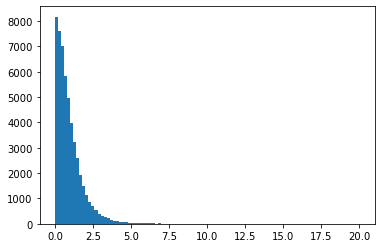

In [81]:
_=plt.hist(data[5], bins=100)

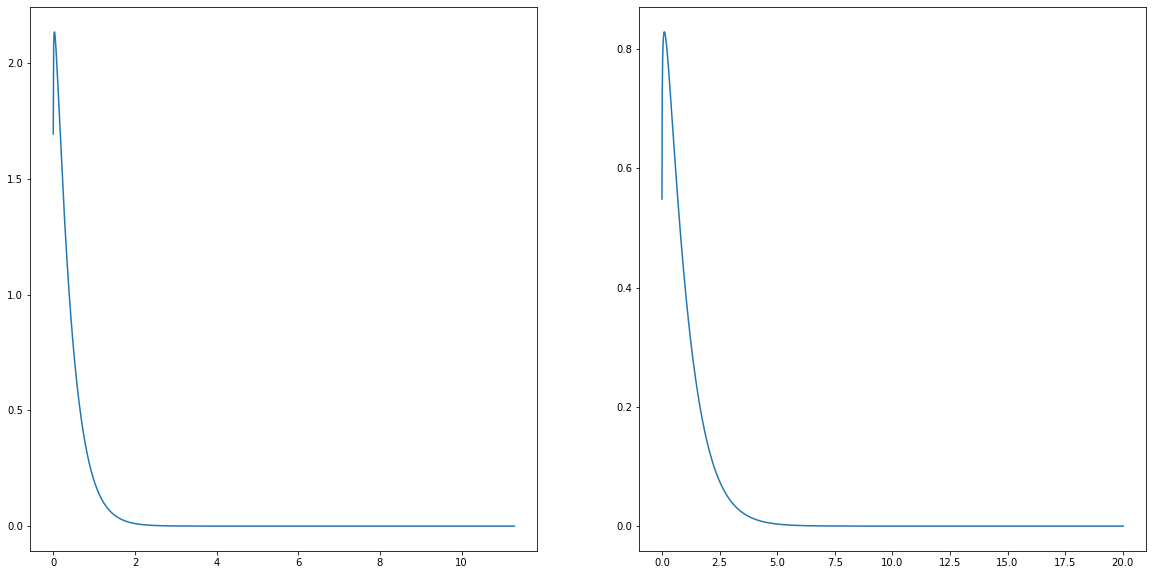

In [98]:
from scipy import stats
import matplotlib.pyplot as plt


fig, ax = plt.subplots(1, 2, figsize=(20,10))


# Using all params and the stats function
c, loc, scale = stats.weibull_min.fit(data[0])
ax[0].plot(data[0],stats.weibull_min.pdf(data[0],c, loc, scale))
c, loc, scale = stats.weibull_min.fit(data[5])
ax[1].plot(data[5],stats.weibull_min.pdf(data[5],c, loc, scale))


